## Imports and Definitions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yaml

In [3]:
from diffpssi.tools import *

from diffpssi.power_sim_lib.backend import *
from diffpssi.power_sim_lib.testbench import TestBench
from diffpssi.power_sim_lib.simulator import Recorder

from diffpssi.power_sim_lib.models.voltage_controller import *

set_matplot_settings(
    font_family="Times New Roman",
    font_size=10,
)

In [4]:
from opt_param_set import *

## Import the Results from the Optimization

In [5]:
output = os.path.join(
    os.path.expanduser("~"),
    "Documents",
    "GitHub",
    "diffpssi_b",
    "paper",
    "2_optimization",
    "data",
    "optimization_data.yaml",
)

results_data = yaml.safe_load(open(output, "r"))

## Regenerate Sims and create Data 

In [6]:
v_refs = []
for res_batch in results_data:
    try:
        v_refs.append(results_data[res_batch]["v_ref"])
        print(results_data[res_batch]["v_ref"])
    except:
        continue

1.3
1.2
1.1
0.9
0.8
0.7


In [7]:
for res_batch in results_data:
    try:
        print(results_data[res_batch]["optimized_parameters"])
    except:
        continue

{'k_d': 0.1714081199459871, 'k_i': 0.7573902653893095}
{'k_d': 0.30216477662040486, 'k_i': 0.6282953744417076}
{'k_d': 0.6025190342178965, 'k_i': 0.43341078977214137}
{'k_d': 0.6492335233456467, 'k_i': 0.40806540344173126}
{'k_d': 0.48398846156900965, 'k_i': 0.5616837189849834}
{'k_d': 0.6463627086606507, 'k_i': 0.3607667543261625}


In [8]:
def get_models(**kwargs):
    analysis_models = [
        [OLTC_Continuous_Milano(param_dict={
            "kd": kwargs.get("k_d"),
            "ki": kwargs.get("k_i"),
            # "kd": 1,
            # "ki": 0.7,
            # "db": 0,
            "m_min": 0.84,
            "m_max": 1.20,
            "v_ref": 1.0
            }), 1],
        [FSM_Only_Discrete(param_dict={
            "t_1": 0.02,
            "db": 0.025,
            "delta_m": 0.04,
            "m_min": 0.84,
            "m_max": 1.20,
            "gamma": 3,
            }), 1],
    ]

    return analysis_models


def record_dict(simulation, call=False):
    record_dict = {
        "Continuous FSM": simulation.diff_models[0].u_l,

        "Discrete FSM": simulation.diff_models[1].u_l,
        # "Integ": simulation.diff_models[1].integ,
        # "v_diff": simulation.diff_models[1].v_diff,
    }
    if call:
        return record_dict.values()
    else:
        return record_dict

In [9]:
results = []

for res_batch in results_data:
    try:
        params = results_data[res_batch]["optimized_parameters"]
        v_ref = results_data[res_batch]["v_ref"]
    except: 
        continue

    models = get_models(**params)

    # function_mock = lambda t: input_function(t, b=v_ref)
    # function_mock = lambda t: jump_input(t, b=v_ref)
    function_mock = lambda t: duplet_input(t, b=(v_ref-1))

    tb = TestBench(
        time_step=0.005,
        sim_time=20,
        inspection_models=get_models(**params),
        input_func=function_mock,
        record_func=record_dict,
        default_runner="run_oltc_control",
        parallel_sims=1,
    )
    # tb.diff_models[0].dir = -1
    tb.diff_models[1].dir = -1

    t, result = tb.run()

    times = tb.input_func(t).reshape(-1, 1, 1)
    x_i = torch.swapaxes(times, 0, 1)
    output = result * x_i

    results.append(output)

recorder_list = tb.record_list()


100%|██████████| 4001/4001 [00:00<00:00, 4870.70it/s]


Dynamic simulation finished in 0.84 seconds


100%|██████████| 4001/4001 [00:00<00:00, 5438.04it/s]


Dynamic simulation finished in 0.74 seconds


100%|██████████| 4001/4001 [00:00<00:00, 5160.86it/s]


...

Dynamic simulation finished in 0.86 seconds


100%|██████████| 4001/4001 [00:00<00:00, 5453.74it/s]


Dynamic simulation finished in 0.74 seconds


100%|██████████| 4001/4001 [00:00<00:00, 5460.18it/s]

Dynamic simulation finished in 0.73 seconds


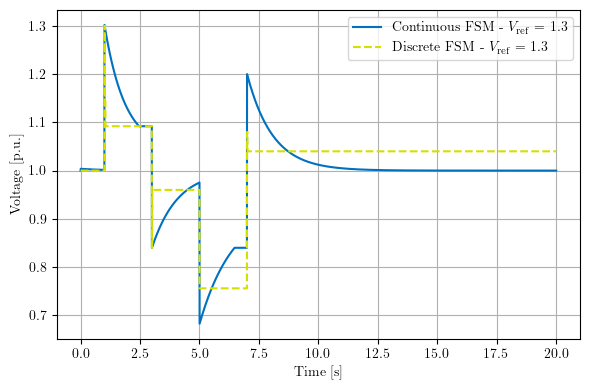

In [10]:
plt.figure(figsize=(6, 4))

# plt.plot(t, results[0][0, :, 1], label=recorder_list[0])

for i in [0]: #range(len(results)):
    plt.plot(t, results[i][0, :, 0], label=f"{recorder_list[0]} - "+ r"$V_\mathrm{ref}=$ " + f"{v_refs[i]}")
    plt.plot(t, results[i][0, :, 1], label=f"{recorder_list[1]} - "+ r"$V_\mathrm{ref}=$ " + f"{v_refs[i]}", linestyle="--")

plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Voltage [p.u.]")
plt.legend()
plt.tight_layout()

plt.savefig("./data/doublet_test.pdf")

plt.show()

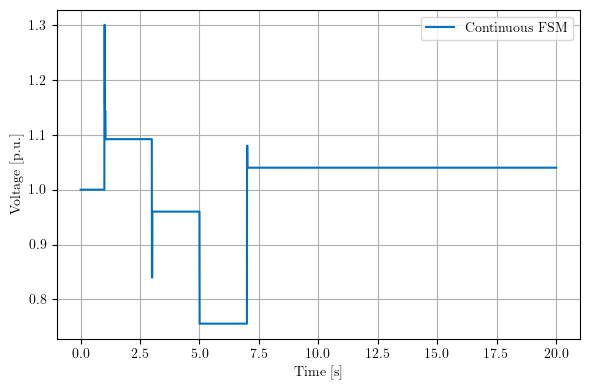

In [11]:
i = 0

plt.figure(figsize=(6, 4))

plt.plot(t, results[i][0, :, 1], label=recorder_list[0])

# plt.plot(t, results[i][0, :, 0], label=f"{recorder_list[0]} opt. step {i}")


plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Voltage [p.u.]")
plt.legend()
plt.tight_layout()
plt.show()

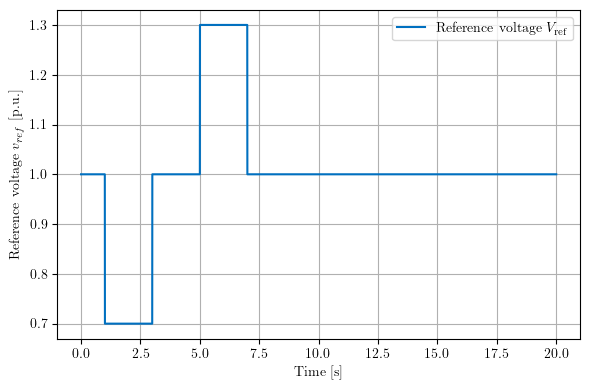

In [12]:
plt.figure(figsize=(6, 4))

plt.plot(t, function_mock(t), label=r"Reference voltage $V_\mathrm{ref}$")

plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Reference voltage $v_{ref}$ [p.u.]")
plt.legend()
plt.tight_layout()
plt.show()

## Looking at Results

In [13]:
loss_convergence = {}
for res_batch in results_data:
    loss_convergence[results_data[res_batch]["v_ref"]] = results_data[res_batch]["minimum_loss"]

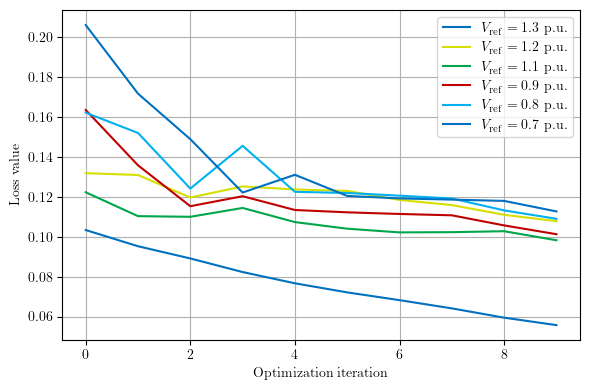

In [14]:
plt.figure(figsize=(6, 4))

for key, val in loss_convergence.items():
    plt.plot(range(len(val)), val, label=fr"$V_\mathrm{{ref}} = {key}$ p.u.")

plt.grid()
plt.xlabel("Optimization iteration")
plt.ylabel("Loss value")
plt.legend()
plt.tight_layout()

plt.savefig("./data/loss_convergence.pdf")

plt.show()

## Fitting a function of kd and ki

In [15]:
controller_parameters = {}
for res_batch in results_data:
    try:
        controller_parameters[results_data[res_batch]["v_ref"]] = (
            [results_data[res_batch]["optimized_parameters"]["k_d"],
            results_data[res_batch]["optimized_parameters"]["k_i"]]
        )
    except:
        continue

controller_parameters

{1.3: [0.1714081199459871, 0.7573902653893095],
 1.2: [0.30216477662040486, 0.6282953744417076],
 1.1: [0.6025190342178965, 0.43341078977214137],
 0.9: [0.6492335233456467, 0.40806540344173126],
 0.8: [0.48398846156900965, 0.5616837189849834],
 0.7: [0.6463627086606507, 0.3607667543261625]}

In [16]:
k_d = []
k_i = []
for i, value in enumerate(controller_parameters.values()):
    k_d.append(value[0])
    k_i.append(value[1])

In [17]:
def fit_function(x, *params):
    return params[0] * (params[1] * np.exp(params[2] * x)) + params[3]

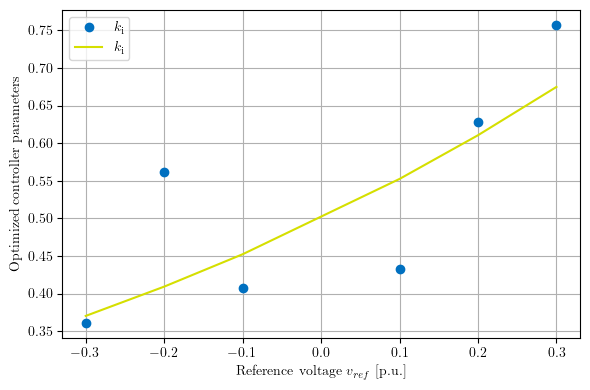

In [52]:
x_values = np.array(list(controller_parameters.keys())) - 1
initial_params_kd = [-1, 0.5, 1, 2]
initial_params_ki = [1, 0.5, 1, 0]

plt.figure(figsize=(6, 4))

# plt.plot(x_values, k_d, "o", label=r"$k_\mathrm{d}$")
# plt.plot(x_values, fit_function(x_values, *initial_params_kd), "o", label=r"$k_\mathrm{d}$")
plt.plot(x_values, k_i, "o", label=r"$k_\mathrm{i}$")
plt.plot(x_values, fit_function(x_values, *initial_params_ki), label=r"$k_\mathrm{i}$")

plt.grid()
plt.legend()
plt.xlabel("Reference voltage $v_{ref}$ [p.u.]")
plt.ylabel("Optimized controller parameters")
plt.tight_layout()


plt.show()

In [53]:
from scipy.optimize import curve_fit

params_kd, _ = curve_fit(
    fit_function,
    xdata=x_values,
    ydata=k_d,
    p0=initial_params_kd,
)

params_ki, _ = curve_fit(
    fit_function,
    xdata=x_values,
    ydata=k_i,
    p0=initial_params_ki,
)

print("Fitted parameters k_d:", params_kd)
print("Fitted parameters k_i:", params_ki)

Fitted parameters k_d: [ 0.32846816 -0.15708199  7.33106927  0.61573239]
Fitted parameters k_i: [0.24239385 0.12151792 8.13992858 0.42884903]


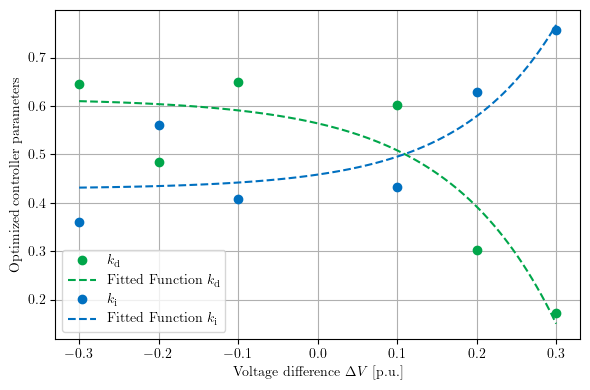

In [64]:
plt.figure(figsize=(6, 4))

smooth_x = np.linspace(min(x_values), max(x_values), 100)

plt.plot(x_values, k_d, "o", color=ees_green, label=r"$k_\mathrm{d}$")
plt.plot(smooth_x, fit_function(smooth_x, *params_kd), color=ees_green, linestyle="--", label=r"Fitted Function $k_\mathrm{d}$")
plt.plot(x_values, k_i, "o", color=ees_blue, label=r"$k_\mathrm{i}$")
plt.plot(smooth_x, fit_function(smooth_x, *params_ki), color=ees_blue, linestyle="--", label=r"Fitted Function $k_\mathrm{i}$")

plt.grid()
plt.legend()
plt.xlabel("Voltage difference $\Delta V$ [p.u.]")
plt.ylabel("Optimized controller parameters")
plt.tight_layout()

plt.savefig("./data/controller_params_fit.pdf")

plt.show()

## Test the Doublet with optimzed Fits

In [60]:
def get_models_fitted(**kwargs):
    analysis_models = [
        [FSM_Continuous_Milano(param_dict={
            "k_d_dependency": kwargs.get("k_d_dependency"),
            "k_i_dependency": kwargs.get("k_i_dependency"),
            # "kd": 1,
            # "ki": 0.7,
            # "db": 0,
            "m_min": 0.84,
            "m_max": 1.20,
            "v_ref": 1.0
            }), 1],
        [FSM_Continuous_Milano(param_dict={
            # "k_d_dependency": kwargs.get("k_d_dependency"),
            # "k_i_dependency": kwargs.get("k_i_dependency"),
            # "kd": 1,
            # "ki": 0.7,
            # "db": 0,
            "m_min": 0.84,
            "m_max": 1.20,
            "v_ref": 1.0
            }), 1],
        [FSM_Only_Discrete(param_dict={
            "t_1": 0.02,
            "db": 0.025,
            "delta_m": 0.04,
            "m_min": 0.84,
            "m_max": 1.20,
            "gamma": 3,
            }), 1],
    ]

    return analysis_models

def record_dict_2(simulation, call=False):
    record_dict = {
        "Continuous FSM - Variable Parameters": simulation.diff_models[0].u_l,
        "Continuous FSM": simulation.diff_models[1].u_l,

        "Discrete FSM": simulation.diff_models[2].u_l,
        # "Integ": simulation.diff_models[1].integ,
        # "v_diff": simulation.diff_models[1].v_diff,
    }
    if call:
        return record_dict.values()
    else:
        return record_dict

In [61]:
function_mock = lambda t: duplet_input(t, b=(v_ref-1))

model_params = {
    "k_d_dependency": lambda v_diff: fit_function(v_diff, *params_kd),
    "k_i_dependency": lambda v_diff: fit_function(v_diff, *params_ki),
}

tb2 = TestBench(
    time_step=0.005,
    sim_time=20,
    inspection_models=get_models_fitted(**model_params),
    input_func=function_mock,
    record_func=record_dict_2,
    default_runner="run_oltc_control",
    parallel_sims=1,
)

# tb2.diff_models[0].dir = -1
tb2.diff_models[2].dir = -1

t_2, result_2 = tb2.run()

times = tb2.input_func(t).reshape(-1, 1, 1)
x_i = torch.swapaxes(times, 0, 1)
output_2 = result_2 * x_i

recorder_list_2 = tb2.record_list()

  0%|          | 0/4001 [00:00<?, ?it/s]/var/folders/4h/hz1klhlj17v3cfnr51n7bmq80000gn/T/ipykernel_31086/4230225971.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return params[0] * (params[1] * np.exp(params[2] * x)) + params[3]
100%|██████████| 4001/4001 [00:01<00:00, 3091.56it/s]

Dynamic simulation finished in 1.30 seconds


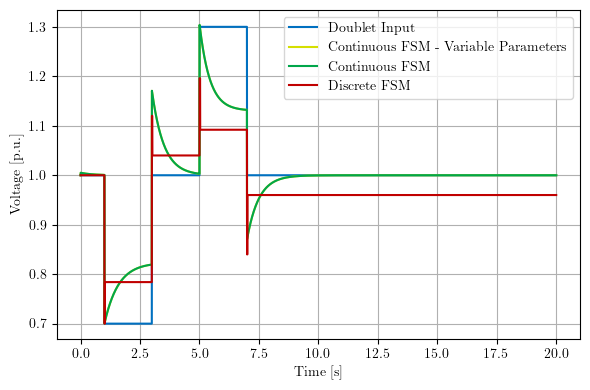

In [65]:
plt.figure(figsize=(6, 4))

plt.plot(t, function_mock(t), label="Doublet Input")
# plt.plot(t, output_2[0, :, 0], label=recorder_list[0])

for i in range(len(recorder_list_2)):
    plt.plot(t, output_2[0, :, i], label=f"{recorder_list_2[i]}")

plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Voltage [p.u.]")
plt.legend()
plt.tight_layout()

plt.savefig("./data/doublet_test.pdf")

plt.show()